In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.model_selection import train_test_split, KFold,cross_validate, StratifiedKFold,GridSearchCV,  RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from scipy.stats import randint
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

df = pd.read_csv('train (1).csv')
df


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [26]:
cols = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    '2ndFlrSF',
    'YearBuilt',
    'YearRemodAdd',
    'FullBath',
    'TotRmsAbvGrd',
    'Fireplaces',
    'LotArea',
    'KitchenQual',
    'ExterQual',
    'YrSold',
    'Neighborhood',
    'OverallCond',
    'BsmtQual',
    'BsmtExposure',
    'GarageFinish',
    'GarageQual',
    'ExterCond',
    'HeatingQC',
    'SalePrice'
]

In [27]:
df = df[cols]
df

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,2ndFlrSF,YearBuilt,YearRemodAdd,FullBath,...,YrSold,Neighborhood,OverallCond,BsmtQual,BsmtExposure,GarageFinish,GarageQual,ExterCond,HeatingQC,SalePrice
0,7,1710,2,548,856,856,854,2003,2003,2,...,2008,CollgCr,5,Gd,No,RFn,TA,TA,Ex,208500
1,6,1262,2,460,1262,1262,0,1976,1976,2,...,2007,Veenker,8,Gd,Gd,RFn,TA,TA,Ex,181500
2,7,1786,2,608,920,920,866,2001,2002,2,...,2008,CollgCr,5,Gd,Mn,RFn,TA,TA,Ex,223500
3,7,1717,3,642,756,961,756,1915,1970,1,...,2006,Crawfor,5,TA,No,Unf,TA,TA,Gd,140000
4,8,2198,3,836,1145,1145,1053,2000,2000,2,...,2008,NoRidge,5,Gd,Av,RFn,TA,TA,Ex,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,460,953,953,694,1999,2000,2,...,2007,Gilbert,5,Gd,No,RFn,TA,TA,Ex,175000
1456,6,2073,2,500,1542,2073,0,1978,1988,2,...,2010,NWAmes,6,Gd,No,Unf,TA,TA,TA,210000
1457,7,2340,1,252,1152,1188,1152,1941,2006,2,...,2010,Crawfor,9,TA,No,RFn,TA,Gd,Ex,266500
1458,5,1078,1,240,1078,1078,0,1950,1996,1,...,2010,NAmes,6,TA,Mn,Unf,TA,TA,Gd,142125


In [28]:
df = df.rename(columns={
    'OverallQual': '전체품질',
    'GrLivArea': '지상생활면적',
    'GarageCars': '차고수용대수',
    'GarageArea': '차고면적',
    'TotalBsmtSF': '지하실총면적',
    '1stFlrSF': '1층면적',
    '2ndFlrSF': '2층면적',
    'YearBuilt': '건축년도',
    'YearRemodAdd': '리모델링년도',
    'FullBath': '욕실수',
    'TotRmsAbvGrd': '총방개수',
    'Fireplaces': '벽난로수',
    'LotArea': '대지면적',
    'KitchenQual': '주방품질',
    'ExterQual': '외관품질',
    'YrSold' : '판매년도',
    'Neighborhood': '동네',
    'OverallCond': '전체상태',
    'BsmtQual': '지하실품질',
    'BsmtExposure': '지하노출도',
    'GarageFinish': '차고마감',
    'GarageQual': '차고품질',
    'ExterCond': '외관상태',
    'HeatingQC': '난방품질',
    'SalePrice': '가격'
})

df

,전체품질,지상생활면적,차고수용대수,차고면적,지하실총면적,1층면적,2층면적,건축년도,리모델링년도,욕실수,...,판매년도,동네,전체상태,지하실품질,지하노출도,차고마감,차고품질,외관상태,난방품질,가격
0,7,1710,2,548,856,856,854,2003,2003,2,...,2008,CollgCr,5,Gd,No,RFn,TA,TA,Ex,208500
1,6,1262,2,460,1262,1262,0,1976,1976,2,...,2007,Veenker,8,Gd,Gd,RFn,TA,TA,Ex,181500
2,7,1786,2,608,920,920,866,2001,2002,2,...,2008,CollgCr,5,Gd,Mn,RFn,TA,TA,Ex,223500
3,7,1717,3,642,756,961,756,1915,1970,1,...,2006,Crawfor,5,TA,No,Unf,TA,TA,Gd,140000
4,8,2198,3,836,1145,1145,1053,2000,2000,2,...,2008,NoRidge,5,Gd,Av,RFn,TA,TA,Ex,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,460,953,953,694,1999,2000,2,...,2007,Gilbert,5,Gd,No,RFn,TA,TA,Ex,175000
1456,6,2073,2,500,1542,2073,0,1978,1988,2,...,2010,NWAmes,6,Gd,No,Unf,TA,TA,TA,210000
1457,7,2340,1,252,1152,1188,1152,1941,2006,2,...,2010,Crawfor,9,TA,No,RFn,TA,Gd,Ex,266500
1458,5,1078,1,240,1078,1078,0,1950,1996,1,...,2010,NAmes,6,TA,Mn,Unf,TA,TA,Gd,142125


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   전체품질    1460 non-null   int64 
 1   지상생활면적  1460 non-null   int64 
 2   차고수용대수  1460 non-null   int64 
 3   차고면적    1460 non-null   int64 
 4   지하실총면적  1460 non-null   int64 
 5   1층면적    1460 non-null   int64 
 6   2층면적    1460 non-null   int64 
 7   건축년도    1460 non-null   int64 
 8   리모델링년도  1460 non-null   int64 
 9   욕실수     1460 non-null   int64 
 10  총방개수    1460 non-null   int64 
 11  벽난로수    1460 non-null   int64 
 12  대지면적    1460 non-null   int64 
 13  주방품질    1460 non-null   object
 14  외관품질    1460 non-null   object
 15  판매년도    1460 non-null   int64 
 16  동네      1460 non-null   object
 17  전체상태    1460 non-null   int64 
 18  지하실품질   1423 non-null   object
 19  지하노출도   1422 non-null   object
 20  차고마감    1379 non-null   object
 21  차고품질    1379 non-null   object
 22  외관상태    1460 non-null   

In [30]:
# 특성공학
qual_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'None':0
}

exposure_map = {
    'Gd': 4,
    'Av': 3,
    'Mn': 2,
    'No': 1,
    'None': 0
}
garage_map = {
    'Fin': 3,
    'RFn': 2,
    'Unf': 1,
    'None': 0
}

neigh_mean = df.groupby('동네')['가격'].mean().to_dict()

df['지하실품질'] = df['지하실품질'].fillna('None')
df['지하노출도'] = df['지하노출도'].fillna('None')
df['차고마감'] = df['차고마감'].fillna('None')
df['차고품질'] = df['차고품질'].fillna('None')
df['동네평균가격'] = df['동네'].map(neigh_mean)
df['차고마감'] = df['차고마감'].map(garage_map)
df['지하노출도'] = df['지하노출도'].map(exposure_map)
df['주방품질'] = df['주방품질'].map(qual_map)
df['지하실품질'] = df['지하실품질'].map(qual_map)
df['외관품질'] = df['외관품질'].map(qual_map)
df['차고품질'] = df['차고품질'].map(qual_map)
df['난방품질'] = df['난방품질'].map(qual_map)
df['외관상태'] = df['외관상태'].map(qual_map)
df['전체면적'] = df['1층면적'] + df['2층면적'] + df['지하실총면적']
df['건물나이'] = df['판매년도'] - df['건축년도']
df['리모델링나이'] = df['판매년도'] - df['리모델링년도']
df['차고수용대수'] = df['차고수용대수'].clip(upper=3)
df['품질_차고'] = df['전체품질'] * df['차고수용대수']
df['면적_차고'] = df['전체면적'] * df['차고면적']
df['지하노출도'] = df['지하노출도'].fillna(0)
df['차고마감'] = df['차고마감'].fillna(0)

df

,전체품질,지상생활면적,차고수용대수,차고면적,지하실총면적,1층면적,2층면적,건축년도,리모델링년도,욕실수,...,차고품질,외관상태,난방품질,가격,동네평균가격,전체면적,건물나이,리모델링나이,품질_차고,면적_차고
0,7,1710,2,548,856,856,854,2003,2003,2,...,3,3,5,208500,197965.773333,2566,5,5,14,1406168
1,6,1262,2,460,1262,1262,0,1976,1976,2,...,3,3,5,181500,238772.727273,2524,31,31,12,1161040
2,7,1786,2,608,920,920,866,2001,2002,2,...,3,3,5,223500,197965.773333,2706,7,6,14,1645248
3,7,1717,3,642,756,961,756,1915,1970,1,...,3,3,4,140000,210624.725490,2473,91,36,21,1587666
4,8,2198,3,836,1145,1145,1053,2000,2000,2,...,3,3,5,250000,335295.317073,3343,8,8,24,2794748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,460,953,953,694,1999,2000,2,...,3,3,5,175000,192854.506329,2600,8,7,12,1196000
1456,6,2073,2,500,1542,2073,0,1978,1988,2,...,3,3,3,210000,189050.068493,3615,32,22,12,1807500
1457,7,2340,1,252,1152,1188,1152,1941,2006,2,...,3,4,5,266500,210624.725490,3492,69,4,7,879984
1458,5,1078,1,240,1078,1078,0,1950,1996,1,...,3,3,4,142125,145847.080000,2156,60,14,5,517440


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   전체품질    1460 non-null   int64  
 1   지상생활면적  1460 non-null   int64  
 2   차고수용대수  1460 non-null   int64  
 3   차고면적    1460 non-null   int64  
 4   지하실총면적  1460 non-null   int64  
 5   1층면적    1460 non-null   int64  
 6   2층면적    1460 non-null   int64  
 7   건축년도    1460 non-null   int64  
 8   리모델링년도  1460 non-null   int64  
 9   욕실수     1460 non-null   int64  
 10  총방개수    1460 non-null   int64  
 11  벽난로수    1460 non-null   int64  
 12  대지면적    1460 non-null   int64  
 13  주방품질    1460 non-null   int64  
 14  외관품질    1460 non-null   int64  
 15  판매년도    1460 non-null   int64  
 16  동네      1460 non-null   object 
 17  전체상태    1460 non-null   int64  
 18  지하실품질   1460 non-null   int64  
 19  지하노출도   1460 non-null   int64  
 20  차고마감    1460 non-null   int64  
 21  차고품질    1460 non-null   int64  
 22  

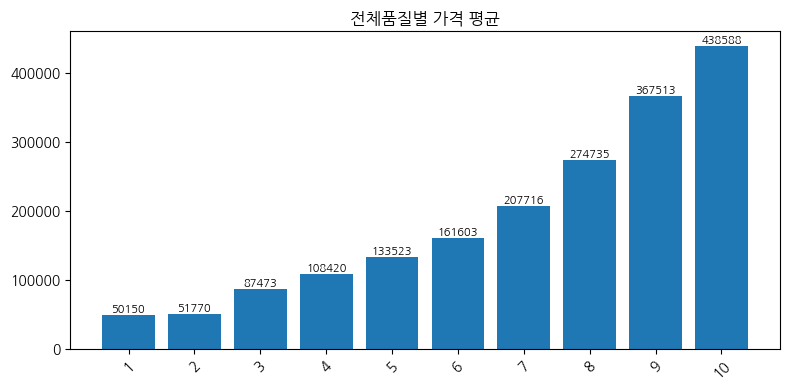

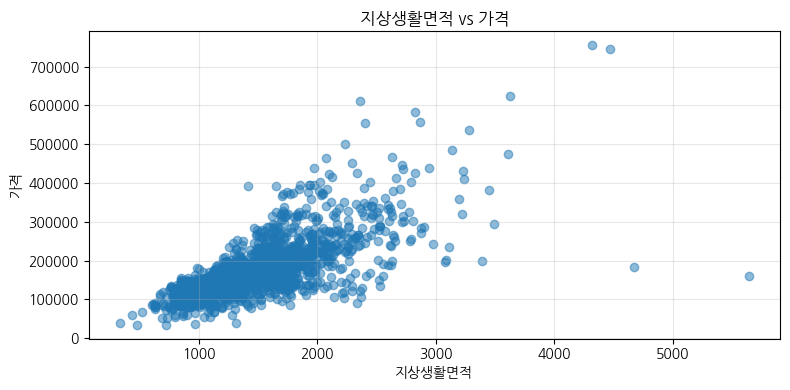

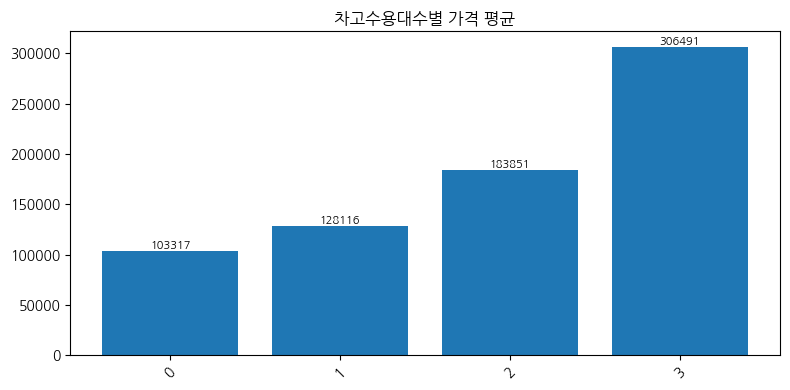

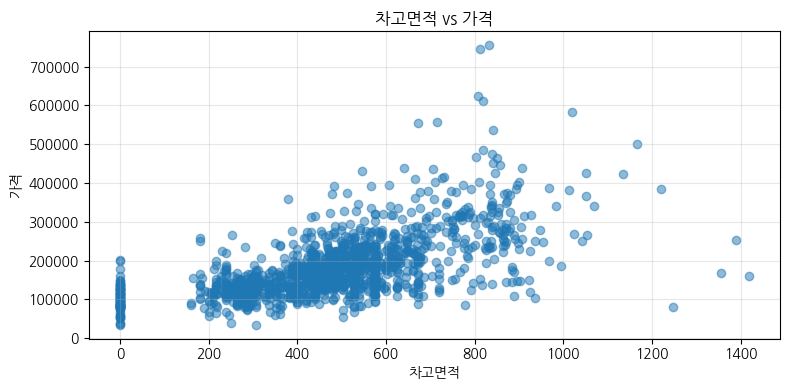

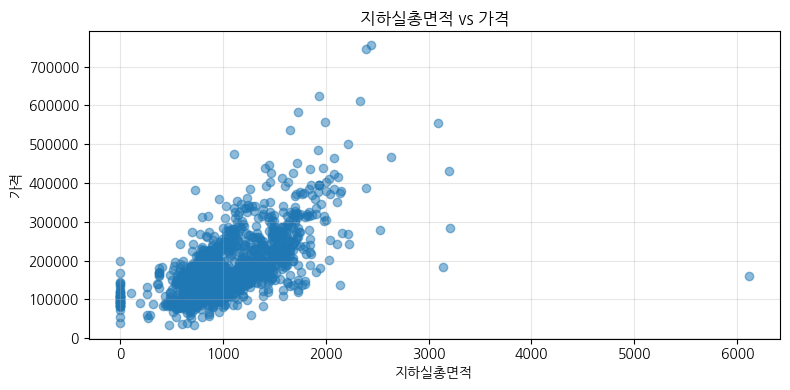

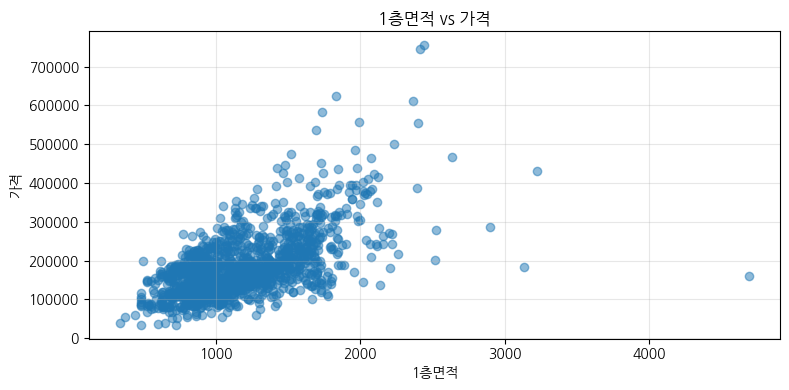

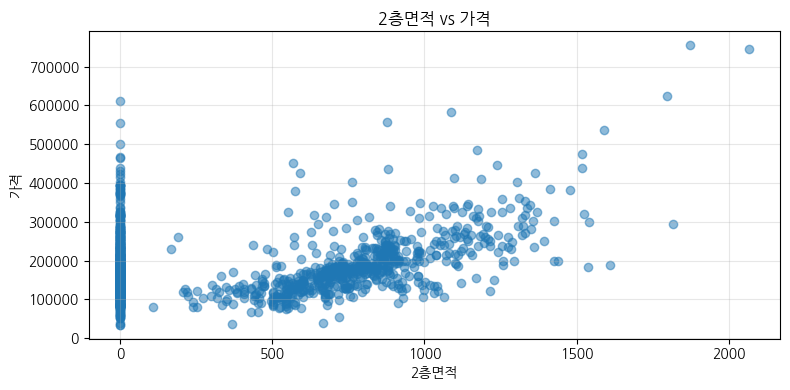

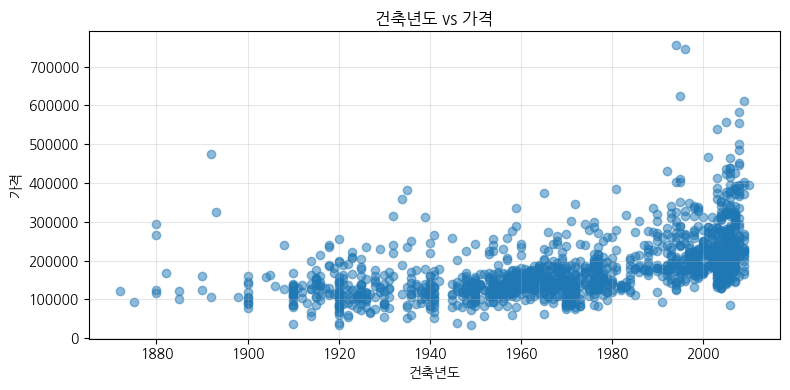

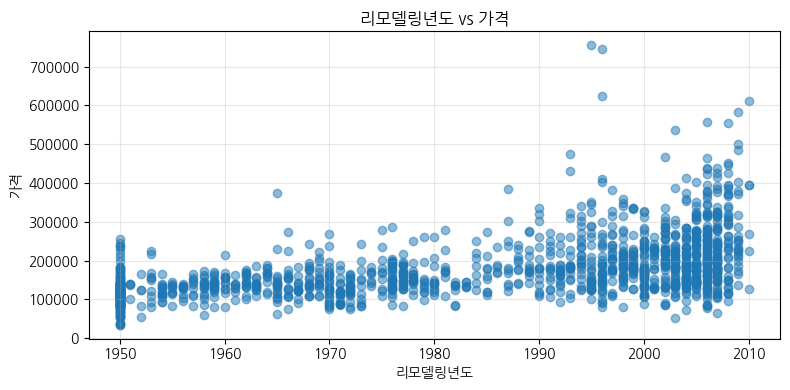

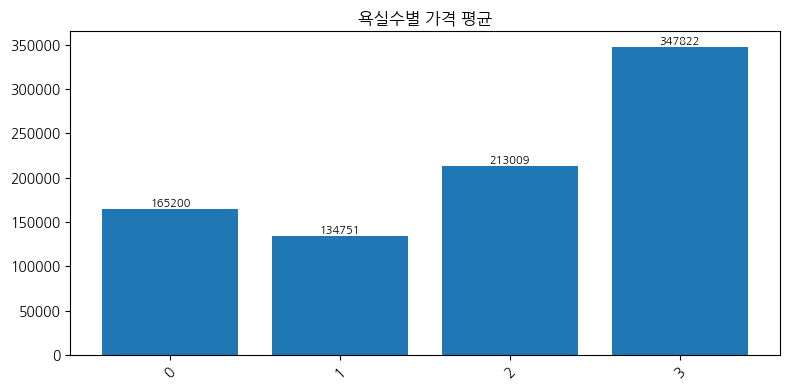

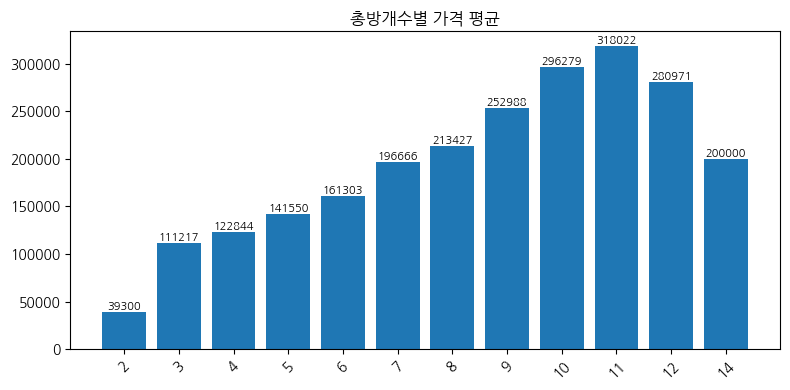

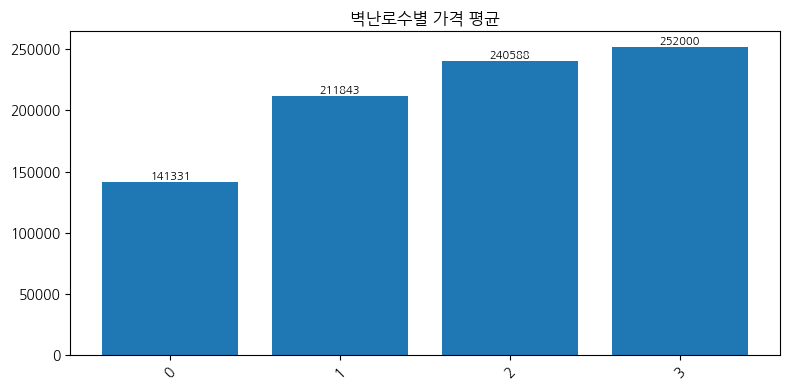

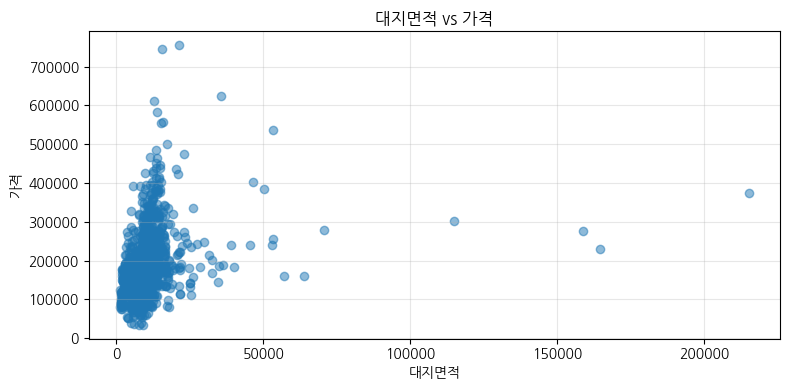

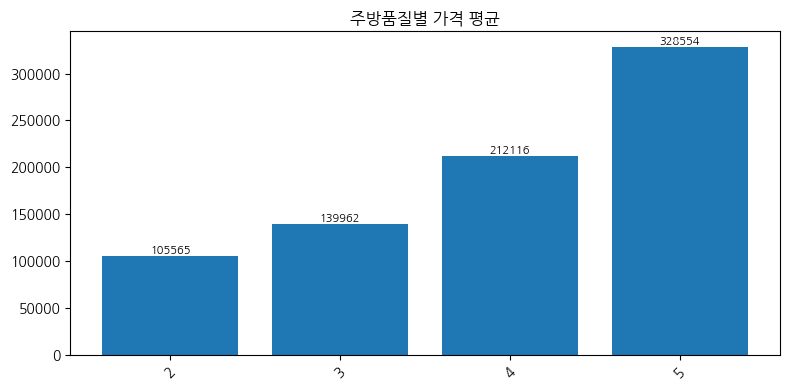

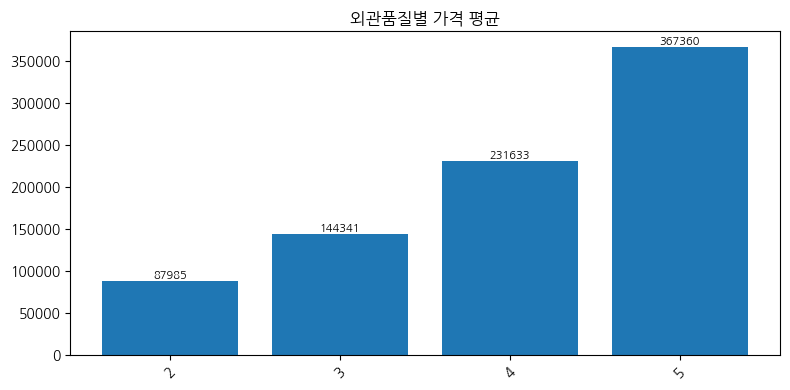

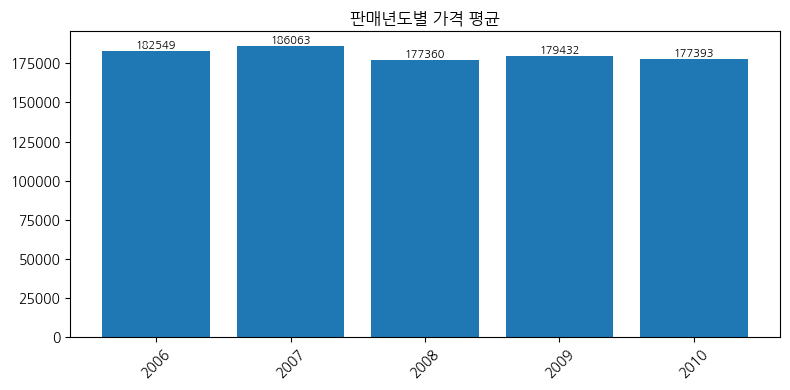

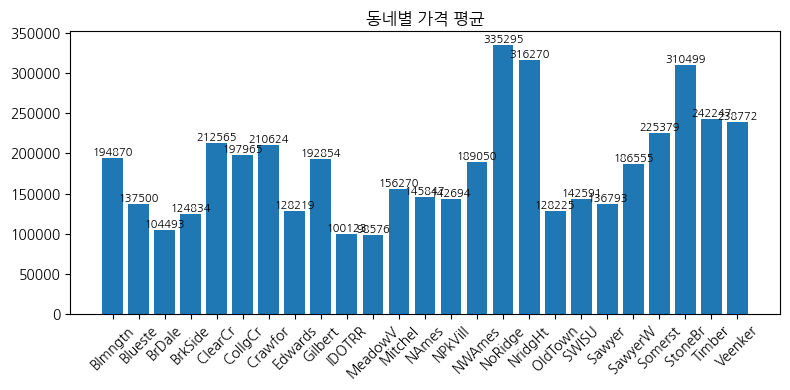

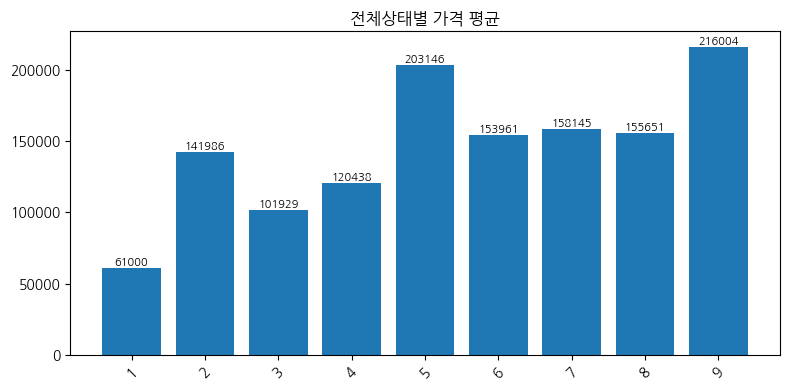

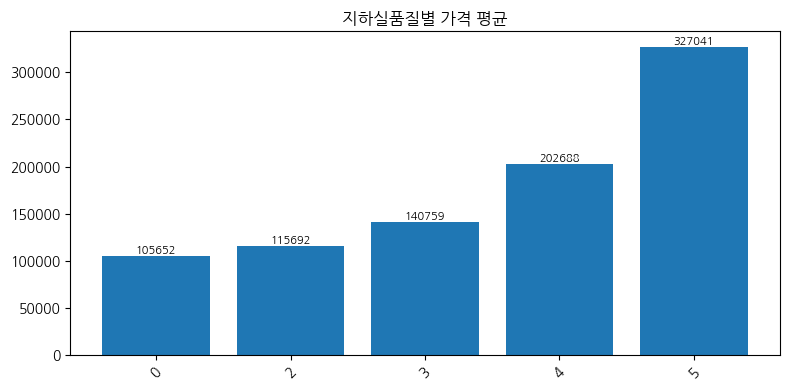

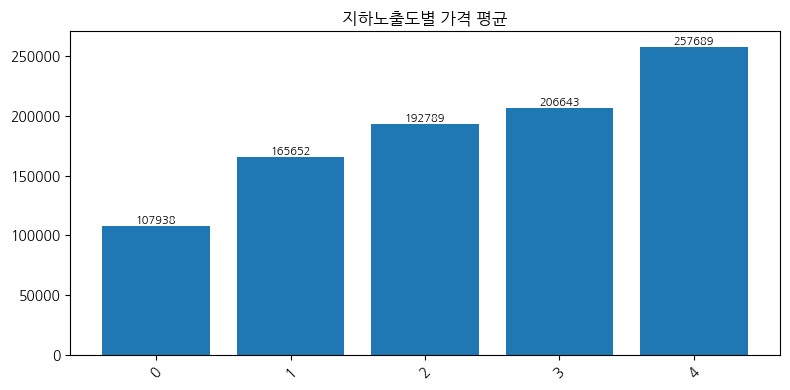

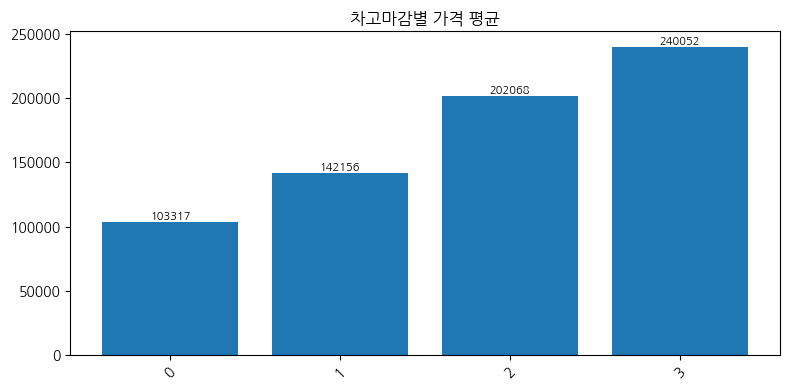

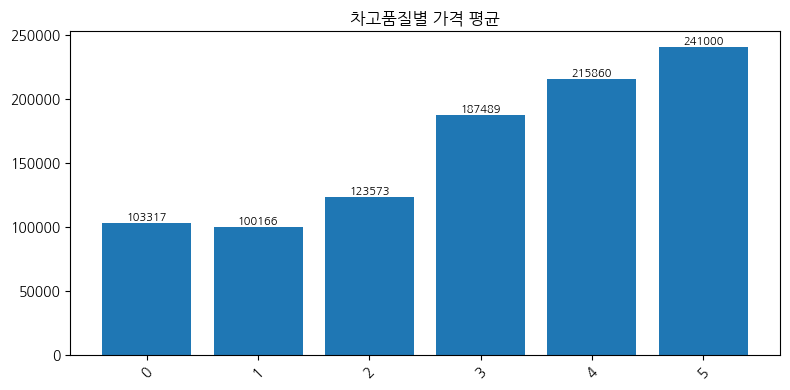

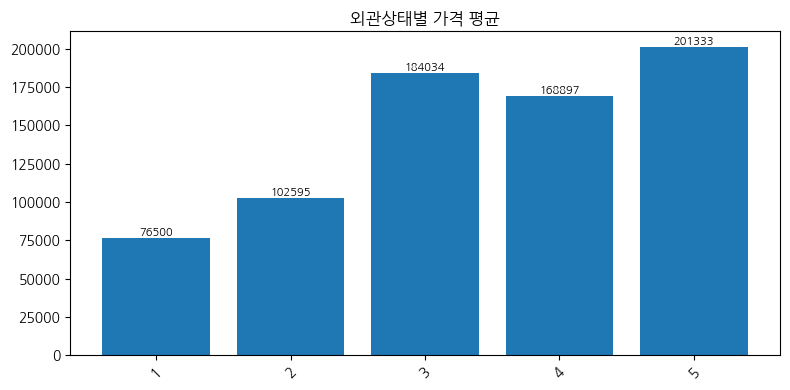

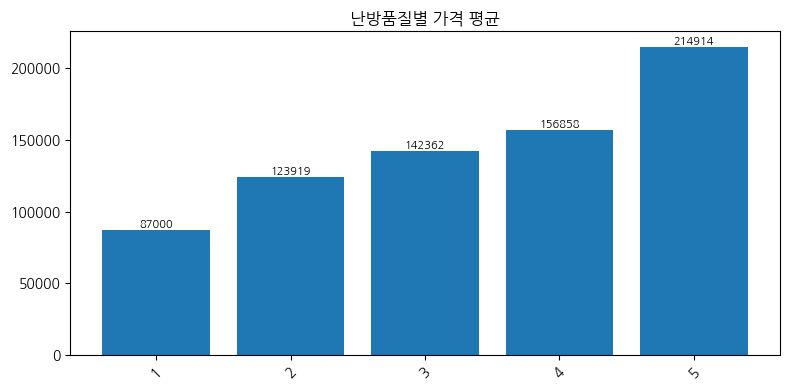

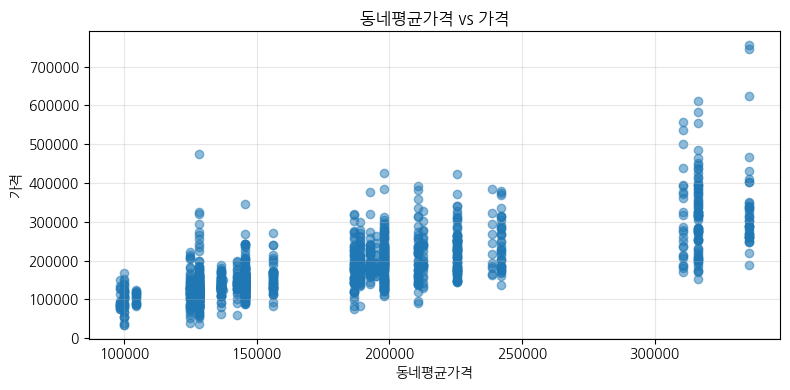

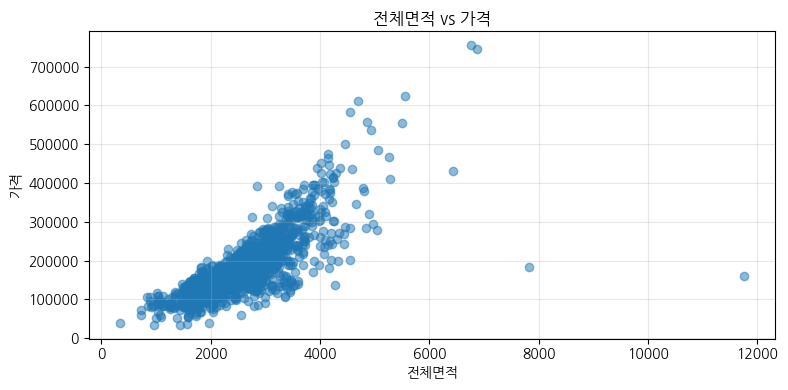

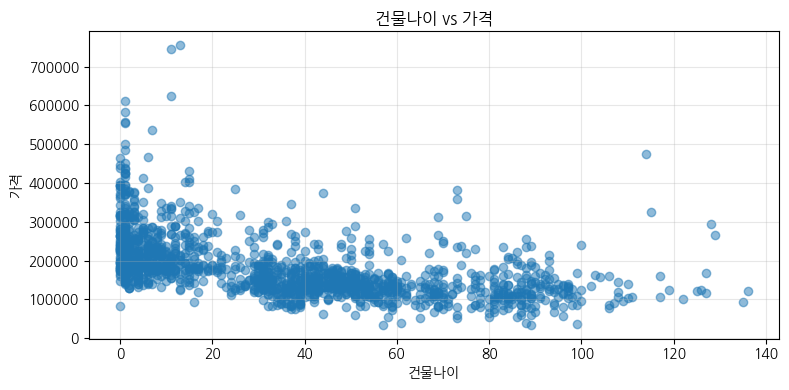

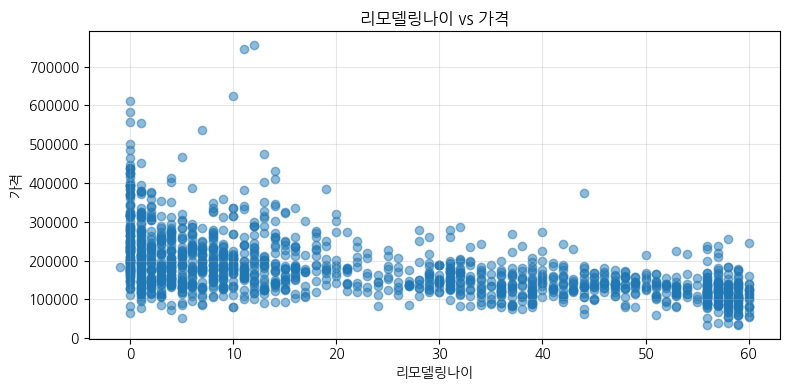

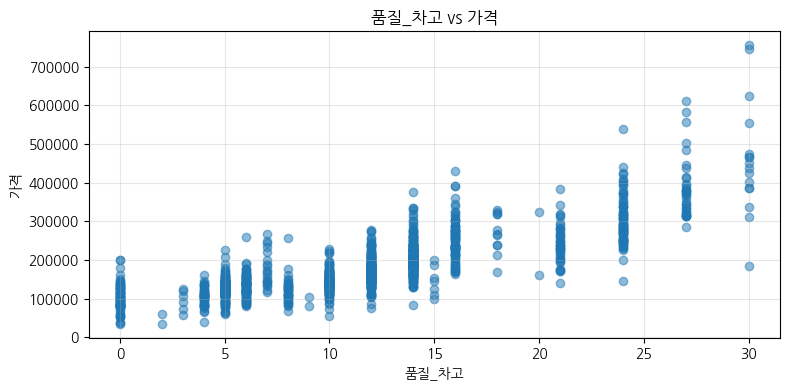

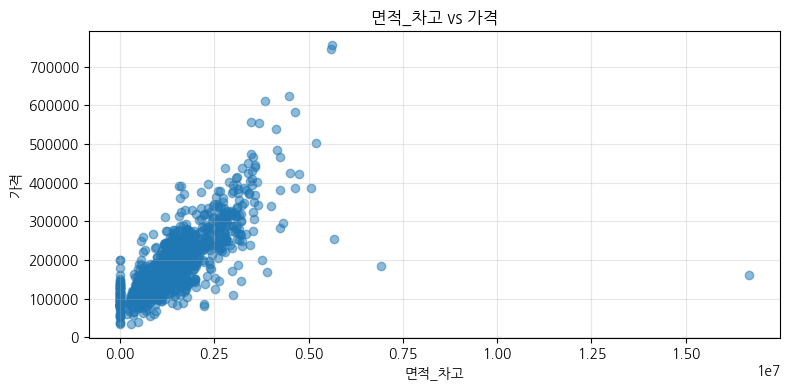

In [32]:
# 시각화
import matplotlib.pyplot as plt

target = '가격'

for col in df.columns:
    if col == target:
        continue

    if df[col].dtype == 'object' or df[col].nunique() <= 15:
        mean_values = df.groupby(col)[target].mean().sort_index()

        plt.figure(figsize=(8, 4))
        x = range(len(mean_values))
        plt.bar(x, mean_values.values)
        plt.xticks(x, mean_values.index, rotation=45)
        plt.title(f'{col}별 {target} 평균')

        for i, v in enumerate(mean_values.values):
            plt.text(i, v, f'{int(v)}', ha='center', va='bottom', fontsize=8)

    else:
        plt.figure(figsize=(8, 4))
        plt.scatter(df[col], df[target], alpha=0.5)
        plt.title(f'{col} vs {target}')
        plt.xlabel(col)
        plt.ylabel(target)
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   전체품질    1460 non-null   int64  
 1   지상생활면적  1460 non-null   int64  
 2   차고수용대수  1460 non-null   int64  
 3   차고면적    1460 non-null   int64  
 4   지하실총면적  1460 non-null   int64  
 5   1층면적    1460 non-null   int64  
 6   2층면적    1460 non-null   int64  
 7   건축년도    1460 non-null   int64  
 8   리모델링년도  1460 non-null   int64  
 9   욕실수     1460 non-null   int64  
 10  총방개수    1460 non-null   int64  
 11  벽난로수    1460 non-null   int64  
 12  대지면적    1460 non-null   int64  
 13  주방품질    1460 non-null   int64  
 14  외관품질    1460 non-null   int64  
 15  판매년도    1460 non-null   int64  
 16  동네      1460 non-null   object 
 17  전체상태    1460 non-null   int64  
 18  지하실품질   1460 non-null   int64  
 19  지하노출도   1460 non-null   int64  
 20  차고마감    1460 non-null   int64  
 21  차고품질    1460 non-null   int64  
 22  

In [34]:
X = df.drop(columns=['가격','동네','전체품질', '주방품질', '외관품질', '지하실품질', '차고품질',
'1층면적', '2층면적', '지하실총면적',
'건축년도', '리모델링년도', '판매년도'])
y = df['가격']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.columns)

Index(['지상생활면적', '차고수용대수', '차고면적', '욕실수', '총방개수', '벽난로수', '대지면적', '전체상태',
       '지하노출도', '차고마감', '외관상태', '난방품질', '동네평균가격', '전체면적', '건물나이', '리모델링나이',
       '품질_차고', '면적_차고'],
      dtype='object')


In [36]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# -----------------------------
# 1. 모델
# -----------------------------
XGBmodel = XGBRegressor(random_state=42)

# -----------------------------
# 2. 파라미터
# -----------------------------
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# -----------------------------
# 3. CV
# -----------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 4. 핵심: 원래 가격 기준 RMSE scorer
# -----------------------------
def rmse_original(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse_original, greater_is_better=False)

# -----------------------------
# 5. GridSearch
# -----------------------------
grid_search = GridSearchCV(
    estimator=XGBmodel,
    param_grid=param_grid,
    scoring=rmse_scorer,   # 🔥 핵심
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# y_train은 로그로 넣는다
grid_search.fit(X_train, np.log1p(y_train))

print("최적 파라미터:", grid_search.best_params_)
print("최고 CV RMSE:", -grid_search.best_score_)  # 이제 원래 가격 기준

# -----------------------------
# 6. 최적 모델 학습
# -----------------------------
bestXGBmodel = grid_search.best_estimator_
bestXGBmodel.fit(X_train, np.log1p(y_train))

# -----------------------------
# 7. 예측
# -----------------------------
y_pred_log = bestXGBmodel.predict(X_test)
y_pred = np.expm1(y_pred_log)

# 안전 처리
y_pred = np.clip(y_pred, 0, None)

# -----------------------------
# 8. 최종 RMSE
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 파라미터: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
최고 CV RMSE: 26799.032830757078
Test RMSE: 25207.903522506585


   feature  importance
16   품질_차고    0.440151
13    전체면적    0.175575
17   면적_차고    0.096369
12  동네평균가격    0.073630
9     차고마감    0.038395
5     벽난로수    0.026558
15  리모델링나이    0.026227
7     전체상태    0.020716
11    난방품질    0.020368
0   지상생활면적    0.017418
14    건물나이    0.013582
8    지하노출도    0.011554
6     대지면적    0.010307
10    외관상태    0.007349
4     총방개수    0.005921
3      욕실수    0.005868
1   차고수용대수    0.005344
2     차고면적    0.004668


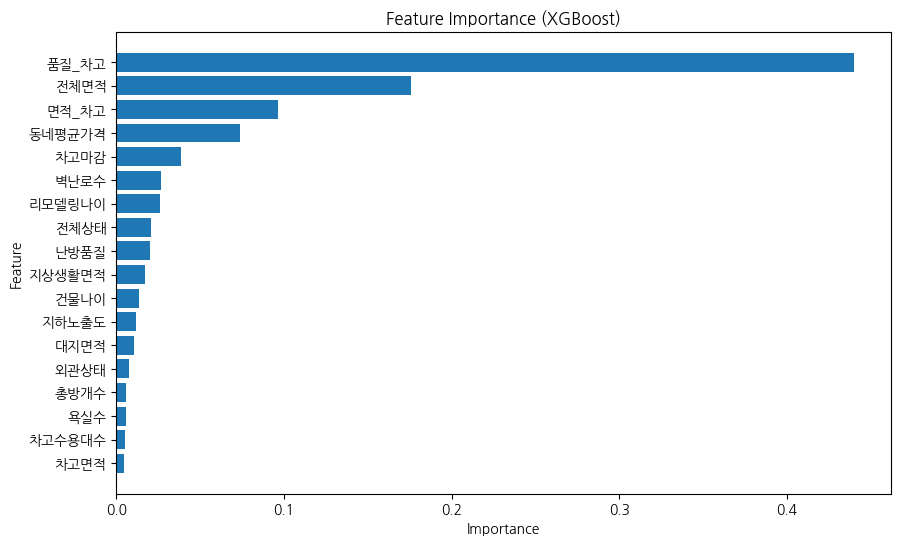

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# 중요도 가져오기
importance = bestXGBmodel.feature_importances_

# 컬럼 이름과 합치기
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
})

# 정렬
feature_importance_df = feature_importance_df.sort_values(
    by='importance', ascending=False
)

print(feature_importance_df)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.gca().invert_yaxis()

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [38]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Lasso, Ridge

RFmodel = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

HGMmodel = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

XGBmodel = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

LGBMmodel = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lr = LinearRegression()

LSmodel = Lasso(alpha=0.0001, random_state=42)

Rmodel = Ridge(alpha=0.01, random_state=42)

===== 모델별 RMSE / 정확도 =====
RandomForest : RMSE = 27592.77, 정확도 ≈ 84.57%
HistGB : RMSE = 26812.35, 정확도 ≈ 85.01%
XGBoost : RMSE = 24653.79, 정확도 ≈ 86.21%
LightGBM : RMSE = 27821.73, 정확도 ≈ 84.44%
Lasso : RMSE = 27082.83, 정확도 ≈ 84.86%
Ridge : RMSE = 27078.66, 정확도 ≈ 84.86%
LinearRegression : RMSE = 27078.57, 정확도 ≈ 84.86%


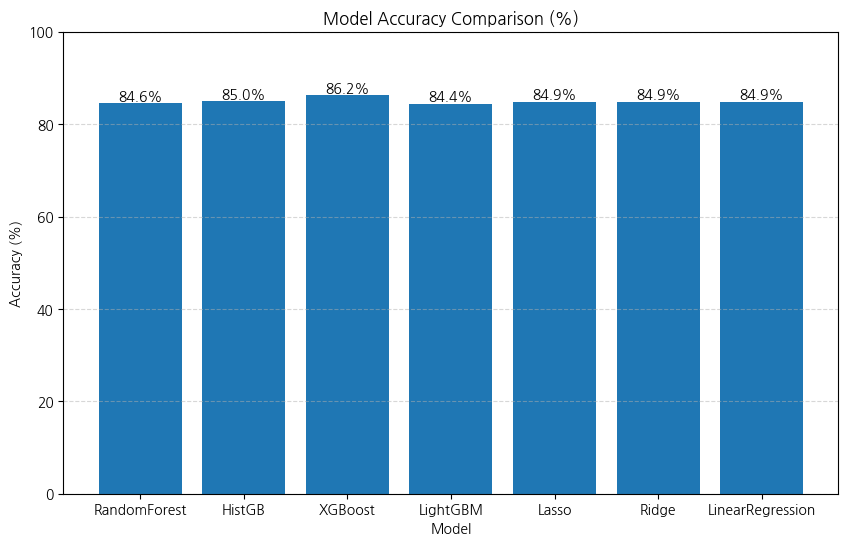

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import mean_squared_error

models = {
    "RandomForest": RFmodel,
    "HistGB": HGMmodel,
    "XGBoost": XGBmodel,
    "LightGBM": LGBMmodel,
    "Lasso": LSmodel,
    "Ridge": Rmodel,
    "LinearRegression" :  lr
}

results = {}
accuracies = {}

# 평균 집값
mean_price = y_test.mean()

for name, model in models.items():
    temp_model = clone(model)
    
    # 로그 학습
    temp_model.fit(X_train, np.log1p(y_train))
    
    # 예측
    y_pred_log = temp_model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)
    
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = rmse
    
    # 정확도 (퍼센트 느낌)
    acc = (1 - (rmse / mean_price)) * 100
    accuracies[name] = acc

print("===== 모델별 RMSE / 정확도 =====")
for name in results:
    print(f"{name} : RMSE = {results[name]:.2f}, 정확도 ≈ {accuracies[name]:.2f}%")

# =========================
# 그래프 (정확도 기준)
# =========================

model_names = list(accuracies.keys())
acc_values = list(accuracies.values())

plt.figure(figsize=(10, 6))
plt.bar(model_names, acc_values)
plt.title("Model Accuracy Comparison (%)")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(acc_values):
    plt.text(i, v, f"{v:.1f}%", ha='center', va='bottom')

plt.show()

In [40]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -----------------------------------
# 1. 모델 모음
# -----------------------------------
models = {
    "RandomForest": RFmodel,
    "HistGB": HGMmodel,
    "XGBoost": XGBmodel,
    "LightGBM": LGBMmodel,
    "Lasso": LSmodel,
    "Ridge": Rmodel,
    "LinearRegression" :  lr
}

# -----------------------------------
# 2. 결과 저장용 리스트
# -----------------------------------
results_list = []

# -----------------------------------
# 3. 각 모델별 학습 / 예측 / 평가
# -----------------------------------
for name, model in models.items():
    temp_model = clone(model)
    
    # 로그 변환해서 학습
    temp_model.fit(X_train, np.log1p(y_train))
    
    # 예측
    y_pred_log = temp_model.predict(X_test)
    
    # 원래 값으로 복원
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)
    
    # 평가 지표 계산
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(y_pred)))
    r2 = r2_score(y_test, y_pred)
    
    # 결과 저장
    results_list.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "RMSLE": rmsle,
        "R2": r2
    })

# -----------------------------------
# 4. DataFrame 생성
# -----------------------------------
results_df = pd.DataFrame(results_list)

# RMSE 기준 정렬 (낮을수록 좋음)
results_df = results_df.sort_values(by="RMSE", ascending=True)

# 보기 좋게 반올림
results_df = results_df.round(4)

# 인덱스 정리
results_df = results_df.reset_index(drop=True)

results_df

,Model,MAE,MSE,RMSE,RMSLE,R2
0,XGBoost,15644.7500,6.078095e+08,24653.7922,0.1369,0.9208
1,HistGB,16575.6872,7.189024e+08,26812.3548,0.1422,0.9063
2,LinearRegression,17275.6881,7.332489e+08,27078.5694,0.1419,0.9044
3,Ridge,17275.7776,7.332539e+08,27078.6618,0.1419,0.9044
4,Lasso,17273.1810,7.334795e+08,27082.8264,0.1419,0.9044
5,RandomForest,16538.0001,7.613607e+08,27592.7655,0.1471,0.9007
6,LightGBM,16954.3699,7.740487e+08,27821.7314,0.1426,0.8991
